# Three-Tier HP Prediction Model

## Model Architecture:
- **Low-CR Model (CR ≤ 1)**: Optimized for very low CR creatures
- **Mid-CR Model (1 < CR ≤ 12)**: Standard model for most creatures
- **High-CR Model (CR > 12)**: Handles legendary/epic creatures

Each model uses the same three-phase approach but with different constraints tuned for their CR range.

In [1]:
# Detect execution context and set paths dynamically
import os
from pathlib import Path

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = 'data'
    PICKLED_MODELS_DIR = 'pickled_models'
    MONSTER_BUILDER_DIR = 'monster-builder-v2'

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")


📁 Execution context detected:
   Current directory: /workspaces/matrix_v0/notebooks
   Data directory: ../data
   Models directory: ../pickled_models


In [2]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Imports successful")

✅ Imports successful


## Load Data

In [3]:
# Load monster dataset (from JSON - has complete action data)
df = pd.read_csv(f'{DATA_DIR}/dnd5e_monsters_from_json.csv')
print(f"📊 Loaded {len(df)} monsters from JSON-based dataset")

# Load Lazy 5e baseline stats
lazy_5e = pd.read_csv(f'{DATA_DIR}/lazy_5e_monster_stats_by_cr.csv')
print(f"📊 Loaded {len(lazy_5e)} CR baselines from Lazy 5e")

print("\n🔍 Lazy 5e Baseline Stats Preview:")
display(lazy_5e.head(10))

📊 Loaded 382 monsters from JSON-based dataset
📊 Loaded 34 CR baselines from Lazy 5e

🔍 Lazy 5e Baseline Stats Preview:


,CR,Eqv_Char_Lvl,AC_DC,HP,Attack_Bonus,Damage_Round,Num_Attacks,Damage_Attack,Example_Monster
0,0,< 1,10,3 (2-4),2,2,1,2 (1d4),"Commoner, rat, spider"
1,1/8,< 1,11,9 (7-11),3,3,1,4 (1d6 + 1),"Bandit, cultist, giant rat"
2,1/4,1,11,13 (10-16),3,5,1,5 (1d6 + 2),"Acolyte, skeleton, wolf"
3,1/2,2,12,22 (17-28),4,8,2,4 (1d4 + 2),"Black bear, scout, shadow"
4,1,3,12,33 (25-41),5,12,2,6 (1d8 + 2),"Dire wolf, specter, spy"
5,2,5,13,45 (34-56),5,17,2,9 (2d6 + 2),"Ghast, ogre, priest"
6,3,7,13,65 (49-81),5,23,2,12 (2d8 + 3),"Knight, mummy, werewolf"
7,4,9,14,84 (64-106),6,28,2,14 (3d8 + 1),"Ettin, ghost"
8,5,10,15,95 (71-119),7,35,3,12 (3d6 + 2),"Elemental, gladiator, vampire spawn"
9,6,11,15,112 (84-140),7,41,3,14 (3d6 + 4),"Mage, medusa, wyvern"


## Parse CR and Create Baseline Lookup Functions

In [4]:
# Parse CR from string to numeric
def parse_cr(cr_str):
    if pd.isna(cr_str):
        return 0
    cr_str = str(cr_str).strip()
    if '/' in cr_str:
        num, denom = cr_str.split('/')
        return float(num) / float(denom)
    try:
        return float(cr_str)
    except:
        return 0

# Convert Lazy 5e CR to numeric
lazy_5e['cr_numeric'] = lazy_5e['CR'].apply(parse_cr)

# Parse HP from Lazy 5e (extract average from "65 (49-81)" format)
def parse_hp_avg(hp_str):
    if pd.isna(hp_str):
        return 0
    match = re.match(r'(\d+)', str(hp_str))
    return int(match.group(1)) if match else 0

lazy_5e['hp_baseline'] = lazy_5e['HP'].apply(parse_hp_avg)

# Adjust HP baselines: +50% for CR <= 1, +20% for CR >= 2
def adjust_hp_baseline(row):
    if row['cr_numeric'] <= 1.0:
        return row['hp_baseline'] * 1.5
    else:
        return row['hp_baseline'] * 1.2

lazy_5e['hp_baseline'] = lazy_5e.apply(adjust_hp_baseline, axis=1)
print("✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2")

# Parse Attack Bonus - handles both numeric (3) and "+3" format
def parse_bonus(bonus_str):
    if pd.isna(bonus_str):
        return 0
    bonus_str = str(bonus_str).strip()
    # Try to match "+3" format first
    match = re.search(r'\+(\d+)', bonus_str)
    if match:
        return int(match.group(1))
    # Try direct numeric format
    try:
        return int(bonus_str)
    except:
        return 0

lazy_5e['attack_baseline'] = lazy_5e['Attack_Bonus'].apply(parse_bonus)
lazy_5e['ac_baseline'] = lazy_5e['AC_DC']
lazy_5e['dpr_baseline'] = lazy_5e['Damage_Round']

print("✅ Parsed Lazy 5e baselines")
print("\n📊 Baseline Stats by CR:")
display(lazy_5e[['cr_numeric', 'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline']].head(15))

✅ Adjusted HP baselines: +50% for CR ≤ 1, +20% for CR ≥ 2
✅ Parsed Lazy 5e baselines

📊 Baseline Stats by CR:


,cr_numeric,hp_baseline,ac_baseline,attack_baseline,dpr_baseline
0,0.000,4.5,10,2,2
1,0.125,13.5,11,3,3
2,0.250,19.5,11,3,5
3,0.500,33.0,12,4,8
4,1.000,49.5,12,5,12
5,2.000,54.0,13,5,17
6,3.000,78.0,13,5,23
7,4.000,100.8,14,6,28
8,5.000,114.0,15,7,35
9,6.000,134.4,15,7,41


In [5]:
# Create interpolation functions for baselines
cr_values = lazy_5e['cr_numeric'].values
hp_baseline_interp = interp1d(cr_values, lazy_5e['hp_baseline'].values, 
                               kind='linear', bounds_error=False, fill_value='extrapolate')
ac_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
                               kind='linear', bounds_error=False, fill_value='extrapolate')
attack_baseline_interp = interp1d(cr_values, lazy_5e['attack_baseline'].values,
                                   kind='linear', bounds_error=False, fill_value='extrapolate')
dpr_baseline_interp = interp1d(cr_values, lazy_5e['dpr_baseline'].values,
                                kind='linear', bounds_error=False, fill_value='extrapolate')
# DC baseline uses same values as AC (from AC_DC column)
dc_baseline_interp = interp1d(cr_values, lazy_5e['ac_baseline'].values,
                               kind='linear', bounds_error=False, fill_value='extrapolate')

def get_baseline_hp(cr):
    return float(hp_baseline_interp(cr))

def get_baseline_ac(cr):
    return float(ac_baseline_interp(cr))

def get_baseline_attack(cr):
    return float(attack_baseline_interp(cr))

def get_baseline_dpr(cr):
    return float(dpr_baseline_interp(cr))

def get_baseline_dc(cr):
    return float(dc_baseline_interp(cr))

print("✅ Created baseline interpolation functions")

✅ Created baseline interpolation functions


## Feature Engineering (Common to All Models)

In [6]:
print("⚙️  FEATURE ENGINEERING")
print("="* 60)

# Parse CR
df['cr_numeric'] = df['Challenge_Rating'].apply(parse_cr)

# Parse AC
def parse_ac(ac_str):
    if pd.isna(ac_str):
        return 10
    match = re.search(r'\d+', str(ac_str))
    return int(match.group()) if match else 10

df['ac_value'] = df['AC'].apply(parse_ac)

# Parse speeds
def parse_speed(speed_str, speed_type):
    if pd.isna(speed_str):
        return 0
    speed_str = str(speed_str).lower()
    if speed_type == 'ground':
        match = re.search(r'^(\d+)\s*ft', speed_str)
        return int(match.group(1)) if match else 0
    else:
        pattern = rf'{speed_type}\s+(\d+)\s*ft'
        match = re.search(pattern, speed_str)
        return int(match.group(1)) if match else 0

df['speed_ground'] = df['Speed'].apply(lambda x: parse_speed(x, 'ground'))
df['speed_fly'] = df['Speed'].apply(lambda x: parse_speed(x, 'fly'))
df['speed_swim'] = df['Speed'].apply(lambda x: parse_speed(x, 'swim'))
df['speed_burrow'] = df['Speed'].apply(lambda x: parse_speed(x, 'burrow'))
df['speed_climb'] = df['Speed'].apply(lambda x: parse_speed(x, 'climb'))

df['max_speed'] = df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']].max(axis=1)
df['movement_types_count'] = (df[['speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb']] > 0).sum(axis=1)
df['has_flying'] = (df['speed_fly'] > 0).astype(int)

# Parse proficiencies
def count_proficiencies(prof_str):
    if pd.isna(prof_str) or str(prof_str).strip() == '':
        return 0
    return len([x.strip() for x in str(prof_str).split(',') if x.strip()])

df['save_proficiency_count'] = df['Saving_Throws'].apply(count_proficiencies)
df['skill_proficiency_count'] = df['Skills'].apply(count_proficiencies)
df['resistance_count'] = df['Resistances'].apply(count_proficiencies)
df['immunity_count'] = df['Immunities'].apply(count_proficiencies)
df['vulnerability_count'] = df['Vulnerabilities'].apply(count_proficiencies)
df['condition_immunity_count'] = df['Condition_Immunities'].apply(count_proficiencies)

print("✅ Basic features parsed")

⚙️  FEATURE ENGINEERING
✅ Basic features parsed


In [7]:
# Parse senses
def has_sense(sense_str, sense_type):
    if pd.isna(sense_str):
        return 0
    return 1 if sense_type in str(sense_str).lower() else 0

def parse_sense_range(sense_str, sense_type):
    if pd.isna(sense_str):
        return 0
    pattern = rf'{sense_type}\s+(\d+)\s*ft'
    match = re.search(pattern, str(sense_str).lower())
    return int(match.group(1)) if match else 0

df['has_darkvision'] = df['Senses'].apply(lambda x: has_sense(x, 'darkvision'))
df['darkvision_range'] = df['Senses'].apply(lambda x: parse_sense_range(x, 'darkvision'))
df['has_blindsight'] = df['Senses'].apply(lambda x: has_sense(x, 'blindsight'))
df['has_truesight'] = df['Senses'].apply(lambda x: has_sense(x, 'truesight'))
df['has_tremorsense'] = df['Senses'].apply(lambda x: has_sense(x, 'tremorsense'))

def parse_passive_perception(sense_str):
    if pd.isna(sense_str):
        return 10
    match = re.search(r'passive\s+perception\s+(\d+)', str(sense_str).lower())
    return int(match.group(1)) if match else 10

df['passive_perception'] = df['Senses'].apply(parse_passive_perception)

print("✅ Senses parsed")

✅ Senses parsed


In [8]:
# Parse abilities from text
def count_abilities(text_str):
    if pd.isna(text_str) or str(text_str).strip() == '':
        return 0
    text = str(text_str).strip()
    entries = [x for x in re.split(r'\n+|\*\s+', text) if x.strip()]
    return len(entries)

df['trait_count'] = df['Traits'].apply(count_abilities)
df['action_count'] = df['Actions'].apply(count_abilities)
df['reaction_count'] = df['Reactions'].apply(count_abilities)
df['bonus_action_count'] = df['Bonus_Actions'].apply(count_abilities)

# Legendary actions
def parse_legendary_actions(leg_str):
    if pd.isna(leg_str) or str(leg_str).strip() == '':
        return 0, 0, 0
    text = str(leg_str).lower()
    has_leg = 1
    count_match = re.search(r'(\d+)\s+legendary\s+actions?', text)
    per_round = int(count_match.group(1)) if count_match else 3
    action_count = len([x for x in re.split(r'\n+|\*\s+', text) if x.strip() and 'can take' not in x.lower()])
    return has_leg, action_count, per_round

df[['has_legendary_actions', 'legendary_action_count', 'legendary_actions_per_round']] = df['Legendary_Actions'].apply(
    lambda x: pd.Series(parse_legendary_actions(x))
)

df['total_ability_count'] = df['trait_count'] + df['action_count'] + df['reaction_count'] + df['legendary_action_count']

print("✅ Ability counts parsed")

✅ Ability counts parsed


In [9]:
# Parse specific abilities
combined_abilities = (df['Traits'].fillna('') + ' ' + df['Actions'].fillna('') + ' ' +
                     df['Reactions'].fillna('') + ' ' + df['Legendary_Actions'].fillna(''))

# Combat metrics - parse from JSON action structures
def parse_attack_bonus(actions_str):
    """Parse attack bonus from JSON-formatted actions"""
    if pd.isna(actions_str):
        return 0
    try:
        actions = json.loads(actions_str)
        bonuses = []
        for action in actions:
            if isinstance(action, dict) and 'Hit Bonus' in action:
                try:
                    bonuses.append(int(action['Hit Bonus']))
                except (ValueError, TypeError):
                    pass
        return max(bonuses) if bonuses else 0
    except (json.JSONDecodeError, TypeError):
        return 0

def parse_save_dc(text_str):
    """Parse save DC from text (traits, actions, reactions, legendary actions)"""
    if pd.isna(text_str):
        return 0
    matches = re.findall(r'dc\s+(\d+)', str(text_str).lower())
    return max([int(m) for m in matches]) if matches else 0

df['highest_attack_bonus'] = df['Actions'].apply(parse_attack_bonus)
df['highest_save_dc'] = combined_abilities.apply(parse_save_dc)

# DPR parser - parse from JSON action structures
def calculate_average_damage(damage_str):
    """Calculate average damage from dice notation like '2d8 + 5'"""
    if not damage_str:
        return 0
    
    total = 0
    # Match patterns like "2d8 + 5" or "1d10+3"
    patterns = re.findall(r'(\d+)d(\d+)(?:\s*[+\-]\s*(\d+))?', str(damage_str))
    
    for match in patterns:
        num_dice = int(match[0])
        die_size = int(match[1])
        modifier = int(match[2]) if match[2] else 0
        avg = num_dice * (die_size + 1) / 2 + modifier
        total += avg
    
    return total

def parse_dpr_from_json(actions_str):
    """
    Parse DPR from JSON action structures.
    Handles multiattack and calculates total DPR.
    
    FIXED: Improved parsing to correctly handle cases like Roper where
    multiattack mentions non-damaging attacks (e.g., "four attacks with tendrils")
    but only some attacks deal damage.
    """
    if pd.isna(actions_str):
        return 0
    
    try:
        actions = json.loads(actions_str)
    except (json.JSONDecodeError, TypeError):
        return 0
    
    # Build a map of attack names to their damage
    attack_damages = {}
    multiattack_desc = None
    
    for action in actions:
        if not isinstance(action, dict):
            continue
        
        name = action.get('Name', '').lower()
        
        if name == 'multiattack':
            multiattack_desc = action.get('Desc', '').lower()
        elif 'Damage' in action:
            # Calculate base damage
            damage = calculate_average_damage(action.get('Damage', ''))
            
            # Add secondary damage if present
            if 'Damage 2' in action:
                damage += calculate_average_damage(action.get('Damage 2', ''))
            
            attack_damages[name] = damage
    
    # If no attacks found, return 0
    if not attack_damages:
        return 0
    
    # If no multiattack, return highest single attack damage
    if not multiattack_desc:
        return max(attack_damages.values())
    
    # Parse multiattack description to determine attack counts
    total_dpr = 0
    attacks_counted = set()
    
    # Try to match specific attacks mentioned in multiattack
    for attack_name, damage in attack_damages.items():
        # Look for patterns like "two beak attacks", "one with its bite", "makes one bite attack"
        patterns = [
            rf'(\w+)\s+{re.escape(attack_name)}\s+attacks?',  # "four bite attacks"
            rf'(\w+)\s+attacks?\s+with\s+(?:its\s+)?{re.escape(attack_name)}',  # "four attacks with its bite"
            rf'makes?\s+(\w+)\s+{re.escape(attack_name)}\s+attacks?',  # "makes one bite attack"
            rf'makes?\s+(\w+)\s+attacks?\s+with\s+(?:its\s+)?{re.escape(attack_name)}',  # "makes one attack with its bite"
        ]
        
        for pattern in patterns:
            match = re.search(pattern, multiattack_desc)
            if match:
                count_word = match.group(1).lower()
                # Convert word to number
                number_map = {
                    'one': 1, 'a': 1, 'an': 1, 'two': 2, 'three': 3, 
                    'four': 4, 'five': 5, 'six': 6
                }
                count = number_map.get(count_word, 0)
                if count == 0:
                    try:
                        count = int(count_word)
                    except ValueError:
                        count = 0
                
                if count > 0:
                    total_dpr += count * damage
                    attacks_counted.add(attack_name)
                    break
    
    # If we found specific attacks, return that total
    if total_dpr > 0:
        return total_dpr
    
    # FALLBACK: If no specific attacks matched, check if generic "makes X attacks" refers to damaging attacks
    # Only use fallback if there's EXACTLY ONE damaging attack type
    if len(attack_damages) == 1:
        match = re.search(r'makes?\s+(\w+)\s+attacks?', multiattack_desc)
        if match:
            count_word = match.group(1).lower()
            number_map = {
                'one': 1, 'a': 1, 'an': 1, 'two': 2, 'three': 3,
                'four': 4, 'five': 5, 'six': 6
            }
            count = number_map.get(count_word, 2)  # Default to 2 if not found
            
            # Check that the generic count isn't referring to a different attack type
            # e.g., "makes four attacks with its tendrils" where tendrils don't do damage
            for attack_name in attack_damages.keys():
                # If the multiattack mentions a different attack type after "makes X attacks"
                # then the count doesn't apply to our damaging attack
                if f'with its {attack_name}' not in multiattack_desc and f'{attack_name} attacks' not in multiattack_desc:
                    # The generic count might be for a non-damaging attack
                    # Look for specific mention of our damaging attack
                    if re.search(rf'(one|a|an|two|three)\s+(?:attack\s+with\s+(?:its\s+)?)?{re.escape(attack_name)}', multiattack_desc):
                        # Found a specific count for our attack, use that instead
                        return max(attack_damages.values())  # Default to 1 attack
            
            total_dpr = count * max(attack_damages.values())
    else:
        # Multiple damaging attacks, can't use generic fallback safely
        # Default: assume 2 attacks with highest damage
        total_dpr = 2 * max(attack_damages.values())
    
    return total_dpr


# Legendary Actions Parser - extracts DPR and conditions
def parse_legendary_actions_dpr(legendary_str):
    """
    Parse legendary actions to extract damage dice, conditions, and calculate DPR.
    Returns: (legendary_dpr, list_of_conditions)
    
    Uses knapsack-style optimization to find damage-maximizing combination within action budget.
    """
    if pd.isna(legendary_str) or str(legendary_str).strip() == '':
        return 0, []
    
    text = str(legendary_str)
    
    # Determine action budget (default 3)
    budget_match = re.search(r'(\d+)\s+legendary\s+actions?', text.lower())
    action_budget = int(budget_match.group(1)) if budget_match else 3
    
    # Split into individual legendary actions
    # Actions are typically separated by double newlines or asterisks
    action_blocks = re.split(r'\n\s*\n|\n\*\s*', text)
    
    legendary_actions = []
    conditions_found = []
    
    condition_keywords = [
        'poisoned', 'blinded', 'charmed', 'deafened', 'frightened',
        'incapacitated', 'paralyzed', 'petrified', 'prone', 'restrained', 'stunned'
    ]
    
    for block in action_blocks:
        if not block.strip():
            continue
        
        # Skip the preamble text
        if 'can take' in block.lower() or 'only one legendary action' in block.lower():
            continue
        
        # Parse action cost (default 1)
        cost_match = re.search(r'\(costs?\s+(\d+)\s+actions?\)', block, re.IGNORECASE)
        cost = int(cost_match.group(1)) if cost_match else 1
        
        # Parse damage from dice notation
        damage = 0
        # Find all damage dice patterns (e.g., "17 (2d6 + 10)" or "2d8+5")
        damage_matches = re.findall(r'(\d+)\s*\((\d+d\d+(?:\s*[+\-]\s*\d+)?)\)', block)
        if damage_matches:
            # Use the average from the first match (number before parentheses)
            damage = int(damage_matches[0][0])
        else:
            # Try to find bare dice notation
            dice_matches = re.findall(r'(\d+)d(\d+)(?:\s*[+\-]\s*(\d+))?', block)
            if dice_matches:
                for match in dice_matches:
                    num_dice = int(match[0])
                    die_size = int(match[1])
                    modifier = int(match[2]) if match[2] else 0
                    damage += num_dice * (die_size + 1) / 2 + modifier
        
        # Parse conditions inflicted
        action_conditions = []
        for condition in condition_keywords:
            if condition in block.lower():
                action_conditions.append(condition)
        
        if damage > 0 or action_conditions:
            legendary_actions.append({
                'cost': cost,
                'damage': damage,
                'conditions': action_conditions
            })
            conditions_found.extend(action_conditions)
    
    # Knapsack-style optimization: find damage-maximizing combination
    # dp[i] = (max_damage, actions_used)
    dp = {0: (0, [])}
    
    for action in legendary_actions:
        cost = action['cost']
        damage = action['damage']
        
        # Update dp table
        new_entries = {}
        for budget_used, (current_damage, actions_used) in dp.items():
            new_budget = budget_used + cost
            if new_budget <= action_budget:
                new_damage = current_damage + damage
                if new_budget not in dp or new_damage > dp[new_budget][0]:
                    new_entries[new_budget] = (new_damage, actions_used + [action])
        
        dp.update(new_entries)
    
    # Find the maximum damage achievable within budget
    max_damage = 0
    for budget_used in range(action_budget + 1):
        if budget_used in dp:
            max_damage = max(max_damage, dp[budget_used][0])
    
    return max_damage, list(set(conditions_found))

df['estimated_dpr'] = df['Actions'].apply(parse_dpr_from_json)

# Parse legendary actions for DPR and conditions
legendary_results = df['Legendary_Actions'].apply(parse_legendary_actions_dpr)
df['legendary_dpr'] = legendary_results.apply(lambda x: x[0])
df['legendary_conditions'] = legendary_results.apply(lambda x: x[1])

# Calculate total DPR (regular actions + legendary actions)
df['total_dpr'] = df['estimated_dpr'] + df['legendary_dpr']

# Special traits
df['has_legendary_resistance'] = combined_abilities.str.contains('legendary resistance', case=False, na=False).astype(int)
df['has_magic_resistance'] = combined_abilities.str.contains('magic resistance', case=False, na=False).astype(int)
df['has_regeneration'] = combined_abilities.str.contains('regeneration', case=False, na=False).astype(int)

# Spellcasting
def parse_spellcasting(text_str):
    if pd.isna(text_str):
        return 0, 0
    text = str(text_str).lower()
    if 'spellcasting' not in text and 'innate spellcasting' not in text:
        return 0, 0
    has_spellcasting = 1
    level_match = re.search(r'(\d+)(?:st|nd|rd|th)[-\s]level\s+spellcaster', text)
    if level_match:
        return has_spellcasting, int(level_match.group(1))
    return has_spellcasting, 0

df[['has_spellcasting', 'spellcaster_level']] = df['Traits'].apply(
    lambda x: pd.Series(parse_spellcasting(x))
)

# Size ordinal
size_map = {'Tiny': 0, 'Small': 1, 'Medium': 2, 'Large': 3, 'Huge': 4, 'Gargantuan': 5}
df['size_ordinal'] = df['Size'].map(size_map).fillna(2)

# Grapple
df['has_grapple'] = combined_abilities.str.contains('grapple', case=False, na=False).astype(int)

print("✅ Special abilities parsed")

✅ Special abilities parsed


In [10]:
# Condition infliction features
conditions = [
    'poisoned', 'blinded', 'charmed', 'deafened', 'frightened',
    'incapacitated', 'paralyzed', 'petrified', 'prone', 'restrained', 'stunned'
]

for condition in conditions:
    feature_name = f'inflicts_{condition}'
    # Check in combined_abilities (regular actions/traits/reactions)
    df[feature_name] = combined_abilities.str.contains(condition, case=False, na=False).astype(int)
    
    # Also check legendary actions conditions
    df[feature_name] = df.apply(
        lambda row: 1 if (row[feature_name] == 1 or condition in row['legendary_conditions']) else 0,
        axis=1
    )

print(f"✅ {len(conditions)} condition features added (including legendary actions)")
print("\n✅ Feature engineering complete")

✅ 11 condition features added (including legendary actions)

✅ Feature engineering complete


## Calculate Baselines and Deviations

In [11]:
print("📊 CALCULATING BASELINES AND DEVIATIONS")
print("=" * 60)

# For each monster, get their CR-based baselines
df['hp_baseline'] = df['cr_numeric'].apply(get_baseline_hp)
df['ac_baseline'] = df['cr_numeric'].apply(get_baseline_ac)
df['attack_baseline'] = df['cr_numeric'].apply(get_baseline_attack)
df['dpr_baseline'] = df['cr_numeric'].apply(get_baseline_dpr)
df['dc_baseline'] = df['cr_numeric'].apply(get_baseline_dc)

# Calculate deviations from baseline
df['ac_deviation'] = df['ac_value'] - df['ac_baseline']
df['attack_deviation'] = df['highest_attack_bonus'] - df['attack_baseline']
df['dpr_deviation'] = df['total_dpr'] - df['dpr_baseline']  # Using total_dpr (includes legendary)

# Save DC deviation: only calculate if creature has a save DC (otherwise 0, no penalty)
df['save_dc_deviation'] = df.apply(
    lambda row: row['highest_save_dc'] - row['dc_baseline'] if row['highest_save_dc'] > 0 else 0,
    axis=1
)

# NOTE: Scaled features (has_flying_scaled, etc.) will be calculated in each tier's
# training cell using hp_after_phase2, not hp_baseline

print("✅ Baselines and deviations calculated")

📊 CALCULATING BASELINES AND DEVIATIONS


✅ Baselines and deviations calculated


In [12]:
# NO phase1_features - hp_baseline is used directly as starting point

# Phase 2: Combat stat deviations + flying (FIXED penalties, not trained)
phase2_features = [
    'ac_deviation',
    'attack_deviation',
    'dpr_deviation',
    'save_dc_deviation',
    'has_flying'  # MOVED from Phase 3 based on correlation analysis
]

# Phase 3: Everything else (LEARNED coefficients)
# Note: scaled features will be calculated using hp_after_phase2
# Note: resistance_count, immunity_count now handled in Phase 1.5
# Note: has_legendary_actions_scaled removed (legendary DPR now in total_dpr)
# Note: has_flying_scaled removed (flying now in Phase 2 with fixed penalty)
phase3_features = [
    'has_legendary_resistance_scaled',
    'has_magic_resistance_scaled',
    'has_regeneration_scaled',
    'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb',
    'max_speed', 'movement_types_count',
    'save_proficiency_count', 'skill_proficiency_count',
    'vulnerability_count', 'condition_immunity_count',
    'has_darkvision', 'darkvision_range', 'has_blindsight', 'has_truesight', 'has_tremorsense',
    'passive_perception',
    'trait_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'legendary_actions_per_round',
    'total_ability_count',
    'has_spellcasting', 'spellcaster_level',
    'size_ordinal', 'has_grapple'
]

# Add condition features to Phase 3
for condition in conditions:
    phase3_features.append(f'inflicts_{condition}')

# Only Phase 3 features are trained (Phase 2 uses fixed penalties)
feature_columns = phase3_features

print(f"📊 Feature Structure:")
print(f"   - Phase 1: hp_baseline (used directly, not a feature)")
print(f"   - Phase 1.5 (Fixed Formula): resistance_count, immunity_count")
print(f"   - Phase 2 (Fixed Penalties): {len(phase2_features)} features (includes flying)")
print(f"   - Phase 3 (Learned): {len(phase3_features)} features")
print(f"   - Total trainable features: {len(feature_columns)}")

📊 Feature Structure:
   - Phase 1: hp_baseline (used directly, not a feature)
   - Phase 1.5 (Fixed Formula): resistance_count, immunity_count
   - Phase 2 (Fixed Penalties): 5 features (includes flying)
   - Phase 3 (Learned): 41 features
   - Total trainable features: 41


## Parse HP and Split Data by CR

In [13]:
# Parse HP from monster data
def parse_hp(hp_str):
    if pd.isna(hp_str):
        return 0
    hp_str = str(hp_str).strip()
    match = re.match(r'(\d+)', hp_str)
    return int(match.group(1)) if match else 0

df['actual_hp'] = df['HP'].apply(parse_hp)

# Remove rows with HP = 0
df_valid = df[df['actual_hp'] > 0].copy()

print(f"✅ Valid samples: {len(df_valid)} monsters with HP > 0")

# Phase 1.5: Calculate HP after resistances/immunities penalties
print("\n🔧 PHASE 1.5: RESISTANCES AND IMMUNITIES")
print("=" * 60)

df_valid['hp_after_phase1'] = df_valid['hp_baseline']

# Calculate resistance/immunity penalties
df_valid['immunity_penalty'] = df_valid['immunity_count'] * 0.50 * df_valid['hp_after_phase1']
df_valid['resistance_penalty'] = df_valid['resistance_count'] * 0.25 * df_valid['hp_after_phase1']
df_valid['total_defensive_penalty'] = df_valid['immunity_penalty'] + df_valid['resistance_penalty']

# Apply 75% cap
df_valid['total_defensive_penalty'] = df_valid['total_defensive_penalty'].clip(
    upper=0.75 * df_valid['hp_after_phase1']
)

df_valid['hp_after_phase1_5'] = df_valid['hp_after_phase1'] - df_valid['total_defensive_penalty']

print("✅ Phase 1.5 complete: Resistances and immunities penalties applied")
print(f"   - Immunity penalty: 50% of HP per immunity")
print(f"   - Resistance penalty: 25% of HP per resistance")
print(f"   - Combined cap: 75% of Phase 1 HP")

# Manual Train/Test Split Function
print("\n🎯 MANUAL TRAIN/TEST SPLIT STRATEGY")
print("=" * 60)

def extract_family(name):
    """Extract creature family from name."""
    name = str(name).lower()
    
    # Dragons
    if 'dragon' in name:
        if 'ancient' in name:
            return 'dragon_ancient'
        elif 'adult' in name:
            return 'dragon_adult'
        elif 'young' in name:
            return 'dragon_young'
        elif 'wyrmling' in name:
            return 'dragon_wyrmling'
        else:
            return 'dragon_other'
    
    # Giants
    if 'giant' in name:
        for giant_type in ['cloud', 'fire', 'frost', 'hill', 'stone', 'storm']:
            if giant_type in name:
                return f'giant_{giant_type}'
        return 'giant_other'
    
    # Goblins/Goblinoids
    if any(x in name for x in ['goblin', 'hobgoblin', 'bugbear']):
        return 'goblinoid'
    
    # Elementals
    if 'elemental' in name:
        return 'elemental'
    
    # Demons
    if 'demon' in name or any(x in name for x in ['balor', 'marilith', 'nalfeshnee', 'vrock', 'hezrou', 'glabrezu']):
        return 'demon'
    
    # Devils
    if 'devil' in name or any(x in name for x in ['pit fiend', 'erinyes', 'bone devil', 'bearded devil']):
        return 'devil'
    
    # Angels
    if 'angel' in name or 'deva' in name or 'solar' in name or 'planetar' in name:
        return 'angel'
    
    # Beasts
    if any(x in name for x in ['wolf', 'bear', 'lion', 'tiger', 'eagle', 'hawk', 'spider', 'snake', 'crocodile', 'shark', 'rat', 'bat', 'frog', 'cat', 'dog', 'horse', 'ox', 'goat']):
        return 'beast'
    
    # Simple humanoids
    if any(x in name for x in ['guard', 'knight', 'noble', 'commoner', 'bandit', 'cultist', 'acolyte', 'priest', 'veteran', 'scout']):
        return 'humanoid_simple'
    
    # Aarakocra, pegasus, etc
    if any(x in name for x in ['aarakocra', 'pegasus', 'griffon', 'hippogriff']):
        return 'simple_flier'
    
    return 'other'

# Manual split lists
TRAIN_CREATURES = [
    # Dragons - TRAIN
    "Young Brass Dragon", "Young Copper Dragon", "Young Bronze Dragon", "Young Blue Dragon", "Young Red Dragon",
    "Adult Brass Dragon", "Adult Black Dragon", "Adult Green Dragon", "Adult Blue Dragon", "Adult Red Dragon",
    "Ancient Brass Dragon", "Ancient Copper Dragon", "Ancient Bronze Dragon", "Ancient Silver Dragon", "Ancient Red Dragon",
    # Demons - TRAIN
    "Vrock", "Glabrezu", "Marilith",
    # Devils - TRAIN
    "Bearded Devil", "Chain Devil", "Horned Devil", "Ice Devil",
    # Angels - TRAIN
    "Deva", "Solar",
    # Elementals - TRAIN
    "Fire Elemental", "Air Elemental",
]

TEST_CREATURES = [
    # Dragons - TEST
    "Young White Dragon", "Young Black Dragon", "Young Green Dragon", "Young Silver Dragon", "Young Gold Dragon",
    "Adult White Dragon", "Adult Copper Dragon", "Adult Bronze Dragon", "Adult Silver Dragon", "Adult Gold Dragon",
    "Ancient White Dragon", "Ancient Black Dragon", "Ancient Green Dragon", "Ancient Blue Dragon", "Ancient Gold Dragon",
    # Demons - TEST
    "Hezrou", "Nalfeshnee", "Balor",
    # Devils - TEST
    "Barbed Devil", "Bone Devil", "Erinyes", "Pit Fiend",
    # Angels - TEST
    "Planetar",
    # Elementals - TEST
    "Earth Elemental", "Water Elemental",
]

# Families that ALL go to training
TRAIN_FAMILIES = [
    'beast', 'humanoid_simple', 'goblinoid', 'simple_flier',
    'giant_cloud', 'giant_fire', 'giant_frost', 'giant_hill',
    'giant_stone', 'giant_storm', 'giant_other'
]

df_valid['family'] = df_valid['Name'].apply(extract_family)

print("Strategy:")
print("  - Simple creatures (beasts, humanoids, goblins, giants, fliers) → ALL TRAINING")
print("  - Complex creatures (dragons, demons, devils, angels, elementals) → SPLIT EVENLY")
print(f"  - Training creatures (manual): {len(TRAIN_CREATURES)}")
print(f"  - Test creatures (manual): {len(TEST_CREATURES)}")
print(f"  - Training families (all): {len(TRAIN_FAMILIES)}")

# Split data by CR (with Phase 1.5 columns)
df_low_cr = df_valid[df_valid['cr_numeric'] <= 1.0].copy()
df_mid_cr = df_valid[(df_valid['cr_numeric'] > 1.0) & (df_valid['cr_numeric'] <= 12.0)].copy()
df_high_cr = df_valid[df_valid['cr_numeric'] > 12.0].copy()

print(f"\n📊 Data Split:")
print(f"   Low-CR (≤ 1):       {len(df_low_cr):3d} monsters")
print(f"   Mid-CR (1-12):      {len(df_mid_cr):3d} monsters")
print(f"   High-CR (> 12):     {len(df_high_cr):3d} monsters")

✅ Valid samples: 382 monsters with HP > 0

🔧 PHASE 1.5: RESISTANCES AND IMMUNITIES
✅ Phase 1.5 complete: Resistances and immunities penalties applied
   - Immunity penalty: 50% of HP per immunity
   - Resistance penalty: 25% of HP per resistance
   - Combined cap: 75% of Phase 1 HP

🎯 MANUAL TRAIN/TEST SPLIT STRATEGY
Strategy:
  - Simple creatures (beasts, humanoids, goblins, giants, fliers) → ALL TRAINING
  - Complex creatures (dragons, demons, devils, angels, elementals) → SPLIT EVENLY
  - Training creatures (manual): 26
  - Test creatures (manual): 25
  - Training families (all): 11



📊 Data Split:
   Low-CR (≤ 1):       172 monsters
   Mid-CR (1-12):      171 monsters
   High-CR (> 12):      39 monsters


## Train Low-CR Model (CR ≤ 1)

In [14]:
print("🤖 TRAINING LOW-CR MODEL (CR ≤ 1)")
print("=" * 80)

# Phase 2 penalties (lighter for low CR)
PHASE2_PENALTIES_LOW = {
    'ac_deviation': -3.0,
    'attack_deviation': -4.0,
    'dpr_deviation': -1.5,
    'save_dc_deviation': -7.0,
    'has_flying': -5.0  # Fixed penalty for flying
}

print("📌 Low-CR Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_LOW.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_low_cr['hp_after_phase2'] = df_low_cr['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_LOW.items():
    df_low_cr['hp_after_phase2'] += df_low_cr[feature] * penalty

# Calculate scaled features using hp_after_phase2 (NO has_flying_scaled)
df_low_cr['has_legendary_resistance_scaled'] = df_low_cr['has_legendary_resistance'] * df_low_cr['hp_after_phase2']
df_low_cr['has_magic_resistance_scaled'] = df_low_cr['has_magic_resistance'] * df_low_cr['hp_after_phase2']
df_low_cr['has_regeneration_scaled'] = df_low_cr['has_regeneration'] * df_low_cr['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_low_cr['residual_hp'] = df_low_cr['actual_hp'] - df_low_cr['hp_after_phase2']

# Prepare Phase 3 data
X_low = df_low_cr[phase3_features].fillna(0)
y_low = df_low_cr['residual_hp']  # Target is residual, not actual HP

# For low-CR: Use all creatures for both training and testing
# (These are simple baseline creatures - we want to validate the model works on them)
X_train_low = X_low
X_test_low = X_low
y_train_low = y_low
y_test_low = y_low

print(f"\n📊 Low-CR Split Strategy:")
print(f"   All low-CR creatures used for both training and testing")
print(f"   Training: {len(X_train_low)} creatures")
print(f"   Test: {len(X_test_low)} creatures (same as training)")

# Standardize
scaler_low = StandardScaler()
X_train_low_scaled = scaler_low.fit_transform(X_train_low)
X_test_low_scaled = scaler_low.transform(X_test_low)

# Train standard linear regression (no constraints)
model_low = LinearRegression()
model_low.fit(X_train_low_scaled, y_train_low)

coef_low = model_low.coef_
intercept_low = model_low.intercept_

# Evaluate using ACTUAL HP (not residual)
# Reconstruct full prediction: hp_after_phase2 + phase3_prediction
df_train = df_low_cr.loc[X_train_low.index]
df_test = df_low_cr.loc[X_test_low.index]

y_pred_residual_train = model_low.predict(X_train_low_scaled)
y_pred_residual_test = model_low.predict(X_test_low_scaled)

y_pred_train_low = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_low = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_low = 1 - np.sum((y_actual_train - y_pred_train_low)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_low = 1 - np.sum((y_actual_test - y_pred_test_low)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_low = np.mean(np.abs(y_actual_test - y_pred_test_low))

print(f"\n📊 Low-CR Model Performance:")
print(f"   Train R²: {train_r2_low:.4f}")
print(f"   Test R²:  {test_r2_low:.4f} (same as train - all creatures used)")
print(f"   Test MAE: {mae_low:.2f} HP")

🤖 TRAINING LOW-CR MODEL (CR ≤ 1)
📌 Low-CR Phase 2 Penalties:
   ac_deviation              = -3.0 HP per point
   attack_deviation          = -4.0 HP per point
   dpr_deviation             = -1.5 HP per point
   save_dc_deviation         = -7.0 HP per point
   has_flying                = -5.0 HP per point

📊 Low-CR Split Strategy:
   All low-CR creatures used for both training and testing
   Training: 172 creatures
   Test: 172 creatures (same as training)

📊 Low-CR Model Performance:
   Train R²: -0.1189
   Test R²:  -0.1189 (same as train - all creatures used)
   Test MAE: 8.57 HP


## Train Mid-CR Model (1 < CR ≤ 12)

In [15]:
print("\n🤖 TRAINING MID-CR MODEL (1 < CR ≤ 12)")
print("=" * 80)

# Phase 2 penalties (standard for mid CR)
PHASE2_PENALTIES_MID = {
    'ac_deviation': -5.0,
    'attack_deviation': -6.0,
    'dpr_deviation': -2.5,
    'save_dc_deviation': -10.0,
    'has_flying': -7.0  # Fixed penalty for flying
}

print("📌 Mid-CR Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_MID.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_mid_cr['hp_after_phase2'] = df_mid_cr['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_MID.items():
    df_mid_cr['hp_after_phase2'] += df_mid_cr[feature] * penalty

# Calculate scaled features using hp_after_phase2 (NO has_flying_scaled)
df_mid_cr['has_legendary_resistance_scaled'] = df_mid_cr['has_legendary_resistance'] * df_mid_cr['hp_after_phase2']
df_mid_cr['has_magic_resistance_scaled'] = df_mid_cr['has_magic_resistance'] * df_mid_cr['hp_after_phase2']
df_mid_cr['has_regeneration_scaled'] = df_mid_cr['has_regeneration'] * df_mid_cr['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_mid_cr['residual_hp'] = df_mid_cr['actual_hp'] - df_mid_cr['hp_after_phase2']

# Prepare Phase 3 data
X_mid = df_mid_cr[phase3_features].fillna(0)
y_mid = df_mid_cr['residual_hp']  # Target is residual, not actual HP

# Manual train/test split
train_mask = pd.Series([False] * len(df_mid_cr), index=df_mid_cr.index)
test_mask = pd.Series([False] * len(df_mid_cr), index=df_mid_cr.index)

# Add simple families to training
for family in TRAIN_FAMILIES:
    family_mask = df_mid_cr['family'] == family
    train_mask |= family_mask

# Add manual TRAIN creatures
for creature_name in TRAIN_CREATURES:
    creature_mask = df_mid_cr['Name'] == creature_name
    if creature_mask.any():
        train_mask |= creature_mask

# Add manual TEST creatures
for creature_name in TEST_CREATURES:
    creature_mask = df_mid_cr['Name'] == creature_name
    if creature_mask.any():
        test_mask |= creature_mask

# Everything else goes to training (default)
remaining_mask = ~(train_mask | test_mask)
train_mask |= remaining_mask

X_train_mid = X_mid[train_mask]
X_test_mid = X_mid[test_mask]
y_train_mid = y_mid[train_mask]
y_test_mid = y_mid[test_mask]

print(f"\n📊 Manual Split:")
print(f"   Training: {len(X_train_mid)} creatures ({len(X_train_mid)/len(X_mid)*100:.1f}%)")
print(f"   Test: {len(X_test_mid)} creatures ({len(X_test_mid)/len(X_mid)*100:.1f}%)")

# Standardize
scaler_mid = StandardScaler()
X_train_mid_scaled = scaler_mid.fit_transform(X_train_mid)
X_test_mid_scaled = scaler_mid.transform(X_test_mid)

# Train standard linear regression (no constraints)
model_mid = LinearRegression()
model_mid.fit(X_train_mid_scaled, y_train_mid)

coef_mid = model_mid.coef_
intercept_mid = model_mid.intercept_

# Evaluate using ACTUAL HP (not residual)
# Reconstruct full prediction: hp_after_phase2 + phase3_prediction
df_train = df_mid_cr.loc[X_train_mid.index]
df_test = df_mid_cr.loc[X_test_mid.index]

y_pred_residual_train = model_mid.predict(X_train_mid_scaled)
y_pred_residual_test = model_mid.predict(X_test_mid_scaled)

y_pred_train_mid = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_mid = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_mid = 1 - np.sum((y_actual_train - y_pred_train_mid)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_mid = 1 - np.sum((y_actual_test - y_pred_test_mid)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_mid = np.mean(np.abs(y_actual_test - y_pred_test_mid))

print(f"\n📊 Mid-CR Model Performance:")
print(f"   Train R²: {train_r2_mid:.4f}")
print(f"   Test R²:  {test_r2_mid:.4f}")
print(f"   Test MAE: {mae_mid:.2f} HP")


🤖 TRAINING MID-CR MODEL (1 < CR ≤ 12)
📌 Mid-CR Phase 2 Penalties:
   ac_deviation              = -5.0 HP per point
   attack_deviation          = -6.0 HP per point
   dpr_deviation             = -2.5 HP per point
   save_dc_deviation         = -10.0 HP per point
   has_flying                = -7.0 HP per point

📊 Manual Split:
   Training: 160 creatures (93.6%)
   Test: 11 creatures (6.4%)

📊 Mid-CR Model Performance:
   Train R²: 0.6013
   Test R²:  -2.3877
   Test MAE: 30.22 HP


## Train High-CR Model (CR > 12)

In [16]:
print("\n🤖 TRAINING HIGH-CR MODEL (CR > 12)")
print("=" * 80)

# Phase 2 penalties (heavier for high CR)
PHASE2_PENALTIES_HIGH = {
    'ac_deviation': -7.0,
    'attack_deviation': -8.0,
    'dpr_deviation': -3.5,
    'save_dc_deviation': -13.0,
    'has_flying': -10.0  # Fixed penalty for flying
}

print("📌 High-CR Phase 2 Penalties:")
for feat, val in PHASE2_PENALTIES_HIGH.items():
    print(f"   {feat:25s} = {val:+.1f} HP per point")

# Calculate HP after Phase 2 (starting from Phase 1.5)
df_high_cr['hp_after_phase2'] = df_high_cr['hp_after_phase1_5'].copy()
for feature, penalty in PHASE2_PENALTIES_HIGH.items():
    df_high_cr['hp_after_phase2'] += df_high_cr[feature] * penalty

# Calculate scaled features using hp_after_phase2 (NO has_flying_scaled)
df_high_cr['has_legendary_resistance_scaled'] = df_high_cr['has_legendary_resistance'] * df_high_cr['hp_after_phase2']
df_high_cr['has_magic_resistance_scaled'] = df_high_cr['has_magic_resistance'] * df_high_cr['hp_after_phase2']
df_high_cr['has_regeneration_scaled'] = df_high_cr['has_regeneration'] * df_high_cr['hp_after_phase2']

# Calculate residual HP (what Phase 3 needs to predict)
df_high_cr['residual_hp'] = df_high_cr['actual_hp'] - df_high_cr['hp_after_phase2']

# Prepare Phase 3 data
X_high = df_high_cr[phase3_features].fillna(0)
y_high = df_high_cr['residual_hp']  # Target is residual, not actual HP

# Manual train/test split
train_mask = pd.Series([False] * len(df_high_cr), index=df_high_cr.index)
test_mask = pd.Series([False] * len(df_high_cr), index=df_high_cr.index)

# Add simple families to training
for family in TRAIN_FAMILIES:
    family_mask = df_high_cr['family'] == family
    train_mask |= family_mask

# Add manual TRAIN creatures
for creature_name in TRAIN_CREATURES:
    creature_mask = df_high_cr['Name'] == creature_name
    if creature_mask.any():
        train_mask |= creature_mask

# Add manual TEST creatures
for creature_name in TEST_CREATURES:
    creature_mask = df_high_cr['Name'] == creature_name
    if creature_mask.any():
        test_mask |= creature_mask

# Everything else goes to training (default)
remaining_mask = ~(train_mask | test_mask)
train_mask |= remaining_mask

X_train_high = X_high[train_mask]
X_test_high = X_high[test_mask]
y_train_high = y_high[train_mask]
y_test_high = y_high[test_mask]

print(f"\n📊 Manual Split:")
print(f"   Training: {len(X_train_high)} creatures ({len(X_train_high)/len(X_high)*100:.1f}%)")
print(f"   Test: {len(X_test_high)} creatures ({len(X_test_high)/len(X_high)*100:.1f}%)")

# Standardize
scaler_high = StandardScaler()
X_train_high_scaled = scaler_high.fit_transform(X_train_high)
X_test_high_scaled = scaler_high.transform(X_test_high)

# Train standard linear regression (no constraints)
model_high = LinearRegression()
model_high.fit(X_train_high_scaled, y_train_high)

coef_high = model_high.coef_
intercept_high = model_high.intercept_

# Evaluate using ACTUAL HP (not residual)
# Reconstruct full prediction: hp_after_phase2 + phase3_prediction
df_train = df_high_cr.loc[X_train_high.index]
df_test = df_high_cr.loc[X_test_high.index]

y_pred_residual_train = model_high.predict(X_train_high_scaled)
y_pred_residual_test = model_high.predict(X_test_high_scaled)

y_pred_train_high = df_train['hp_after_phase2'].values + y_pred_residual_train
y_pred_test_high = df_test['hp_after_phase2'].values + y_pred_residual_test

y_actual_train = df_train['actual_hp'].values
y_actual_test = df_test['actual_hp'].values

train_r2_high = 1 - np.sum((y_actual_train - y_pred_train_high)**2) / np.sum((y_actual_train - y_actual_train.mean())**2)
test_r2_high = 1 - np.sum((y_actual_test - y_pred_test_high)**2) / np.sum((y_actual_test - y_actual_test.mean())**2)
mae_high = np.mean(np.abs(y_actual_test - y_pred_test_high))

print(f"\n📊 High-CR Model Performance:")
print(f"   Train R²: {train_r2_high:.4f}")
print(f"   Test R²:  {test_r2_high:.4f}")
print(f"   Test MAE: {mae_high:.2f} HP")


🤖 TRAINING HIGH-CR MODEL (CR > 12)
📌 High-CR Phase 2 Penalties:
   ac_deviation              = -7.0 HP per point
   attack_deviation          = -8.0 HP per point
   dpr_deviation             = -3.5 HP per point
   save_dc_deviation         = -13.0 HP per point
   has_flying                = -10.0 HP per point

📊 Manual Split:
   Training: 25 creatures (64.1%)
   Test: 14 creatures (35.9%)

📊 High-CR Model Performance:
   Train R²: 0.9910
   Test R²:  -3.5414
   Test MAE: 132.74 HP


## Save All Models

In [17]:
print("\n💾 SAVING ALL MODELS")
print("=" * 80)

# Save Low-CR Model
model_low_dict = {
    'coef': coef_low,
    'intercept': intercept_low,
    'scaler': scaler_low,
    'feature_columns': phase3_features,  # Only Phase 3
    'phase2_penalties': PHASE2_PENALTIES_LOW,
    'cr_range': (0, 1.0),
    'test_r2': test_r2_low,
    'test_mae': mae_low
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_low_cr.pkl', 'wb') as f:
    pickle.dump(model_low_dict, f)
print("✅ Saved: ../pickled_models/hp_model_low_cr.pkl")

# Save Mid-CR Model
model_mid_dict = {
    'coef': coef_mid,
    'intercept': intercept_mid,
    'scaler': scaler_mid,
    'feature_columns': phase3_features,  # Only Phase 3
    'phase2_penalties': PHASE2_PENALTIES_MID,
    'cr_range': (1.0, 12.0),
    'test_r2': test_r2_mid,
    'test_mae': mae_mid
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_mid_cr.pkl', 'wb') as f:
    pickle.dump(model_mid_dict, f)
print("✅ Saved: ../pickled_models/hp_model_mid_cr.pkl")

# Save High-CR Model
model_high_dict = {
    'coef': coef_high,
    'intercept': intercept_high,
    'scaler': scaler_high,
    'feature_columns': phase3_features,  # Only Phase 3
    'phase2_penalties': PHASE2_PENALTIES_HIGH,
    'cr_range': (12.0, 30.0),
    'test_r2': test_r2_high,
    'test_mae': mae_high
}

with open(f'{PICKLED_MODELS_DIR}/hp_model_high_cr.pkl', 'wb') as f:
    pickle.dump(model_high_dict, f)
print("✅ Saved: ../pickled_models/hp_model_high_cr.pkl")

# Save baseline lookup data
baseline_data = {
    'cr_values': lazy_5e['cr_numeric'].tolist(),
    'hp_baseline': lazy_5e['hp_baseline'].tolist(),
    'ac_baseline': lazy_5e['ac_baseline'].tolist(),
    'attack_baseline': lazy_5e['attack_baseline'].tolist(),
    'dpr_baseline': lazy_5e['dpr_baseline'].tolist(),
    'dc_baseline': lazy_5e['ac_baseline'].tolist()  # Same as AC
}

with open(f'{DATA_DIR}/baseline_lookup_three_tier.json', 'w') as f:
    json.dump(baseline_data, f, indent=2)
print("✅ Saved: ../data/baseline_lookup_three_tier.json")


💾 SAVING ALL MODELS
✅ Saved: ../pickled_models/hp_model_low_cr.pkl
✅ Saved: ../pickled_models/hp_model_mid_cr.pkl
✅ Saved: ../pickled_models/hp_model_high_cr.pkl
✅ Saved: ../data/baseline_lookup_three_tier.json


## Export for Web App

In [18]:
print("\n📦 EXPORTING FOR WEB APP")
print("=" * 80)

# Helper function to unscale coefficients
def unscale_coefficients(coef, scaler, feature_columns):
    return {feat: float(coef[i] / scaler.scale_[i]) 
            for i, feat in enumerate(feature_columns)}

# Export all three models
web_export = {
    'model_type': 'three_tier_hp_model_sequential',
    'description': 'Sequential three-phase model with fixed Phase 2 penalties',
    'baseline_data': baseline_data,
    'phase2_features': phase2_features,
    'phase3_features': phase3_features,
    
    'models': {
        'low_cr': {
            'cr_range': [0, 1.0],
            'phase2_penalties': PHASE2_PENALTIES_LOW,
            'phase3_model': {
                'intercept': float(intercept_low),
                'coefficients': unscale_coefficients(coef_low, scaler_low, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_low.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_low.scale_)}
            },
            'test_r2': float(test_r2_low),
            'test_mae': float(mae_low)
        },
        'mid_cr': {
            'cr_range': [1.0, 12.0],
            'phase2_penalties': PHASE2_PENALTIES_MID,
            'phase3_model': {
                'intercept': float(intercept_mid),
                'coefficients': unscale_coefficients(coef_mid, scaler_mid, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_mid.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_mid.scale_)}
            },
            'test_r2': float(test_r2_mid),
            'test_mae': float(mae_mid)
        },
        'high_cr': {
            'cr_range': [12.0, 30.0],
            'phase2_penalties': PHASE2_PENALTIES_HIGH,
            'phase3_model': {
                'intercept': float(intercept_high),
                'coefficients': unscale_coefficients(coef_high, scaler_high, phase3_features),
                'scaler_mean': {feat: float(m) for feat, m in zip(phase3_features, scaler_high.mean_)},
                'scaler_scale': {feat: float(s) for feat, s in zip(phase3_features, scaler_high.scale_)}
            },
            'test_r2': float(test_r2_high),
            'test_mae': float(mae_high)
        }
    }
}

with open(f'{MONSTER_BUILDER_DIR}/model_data.json', 'w') as f:
    json.dump(web_export, f, indent=2)
print("✅ Saved: ../monster-builder-v2/model_data.json")

print("\n✅ All models exported successfully!")


📦 EXPORTING FOR WEB APP
✅ Saved: ../monster-builder-v2/model_data.json

✅ All models exported successfully!


## Summary

In [19]:
print("\n" + "=" * 80)
print("🎉 THREE-TIER HP MODEL TRAINING COMPLETE")
print("=" * 80)

print("\n📊 MODEL PERFORMANCE SUMMARY:")
print(f"\n   Low-CR Model (CR ≤ 1):")
print(f"      Training samples: {len(y_train_low)}")
print(f"      Test R²:  {test_r2_low:.4f}")
print(f"      Test MAE: {mae_low:.2f} HP")

print(f"\n   Mid-CR Model (1 < CR ≤ 12):")
print(f"      Training samples: {len(y_train_mid)}")
print(f"      Test R²:  {test_r2_mid:.4f}")
print(f"      Test MAE: {mae_mid:.2f} HP")

print(f"\n   High-CR Model (CR > 12):")
print(f"      Training samples: {len(y_train_high)}")
print(f"      Test R²:  {test_r2_high:.4f}")
print(f"      Test MAE: {mae_high:.2f} HP")

print("\n📁 Files Created:")
print("   ✅ pickled_models/hp_model_low_cr.pkl")
print("   ✅ pickled_models/hp_model_mid_cr.pkl")
print("   ✅ pickled_models/hp_model_high_cr.pkl")
print("   ✅ data/baseline_lookup_three_tier.json")
print("   ✅ monster-builder-v2/model_data.json (web app export)")

print("\n✨ Ready for integration into monster-builder-v2!")


🎉 THREE-TIER HP MODEL TRAINING COMPLETE

📊 MODEL PERFORMANCE SUMMARY:

   Low-CR Model (CR ≤ 1):
      Training samples: 172
      Test R²:  -0.1189
      Test MAE: 8.57 HP

   Mid-CR Model (1 < CR ≤ 12):
      Training samples: 160
      Test R²:  -2.3877
      Test MAE: 30.22 HP

   High-CR Model (CR > 12):
      Training samples: 25
      Test R²:  -3.5414
      Test MAE: 132.74 HP

📁 Files Created:
   ✅ pickled_models/hp_model_low_cr.pkl
   ✅ pickled_models/hp_model_mid_cr.pkl
   ✅ pickled_models/hp_model_high_cr.pkl
   ✅ data/baseline_lookup_three_tier.json
   ✅ monster-builder-v2/model_data.json (web app export)

✨ Ready for integration into monster-builder-v2!


## ANALYZING BEST AND WORST PREDICTIONS

🔍 ANALYZING BEST AND WORST PREDICTIONS

Low-CR (CR ≤ 1) - Best 10 Predictions:
              Name    CR  Actual_HP  Predicted_HP         Error Split
        Troll Limb 0.500         14     14.000000  1.065814e-14 Train
           Acolyte 0.250          9      9.000000 -1.776357e-14 Train
   Avatar of Death 0.000          1      1.000000 -3.552714e-14 Train
         Death Dog 1.000         39     39.000000  6.394885e-14 Train
        Cockatrice 0.500         27     27.000000 -7.815970e-14 Train
        Ice Mephit 0.500         21     21.000000 -8.881784e-14 Train
Diseased Giant Rat 0.125          7      7.067650 -6.764990e-02 Train
       Giant Eagle 1.000         26     25.888216  1.117841e-01 Train
           Panther 0.250         13     12.864993  1.350066e-01 Train
              Drow 0.250         13     12.854561  1.454393e-01 Train

Low-CR (CR ≤ 1) - Worst 10 Predictions:
                  Name    CR  Actual_HP  Predicted_HP      Error Split
                Stirge 0.125          2

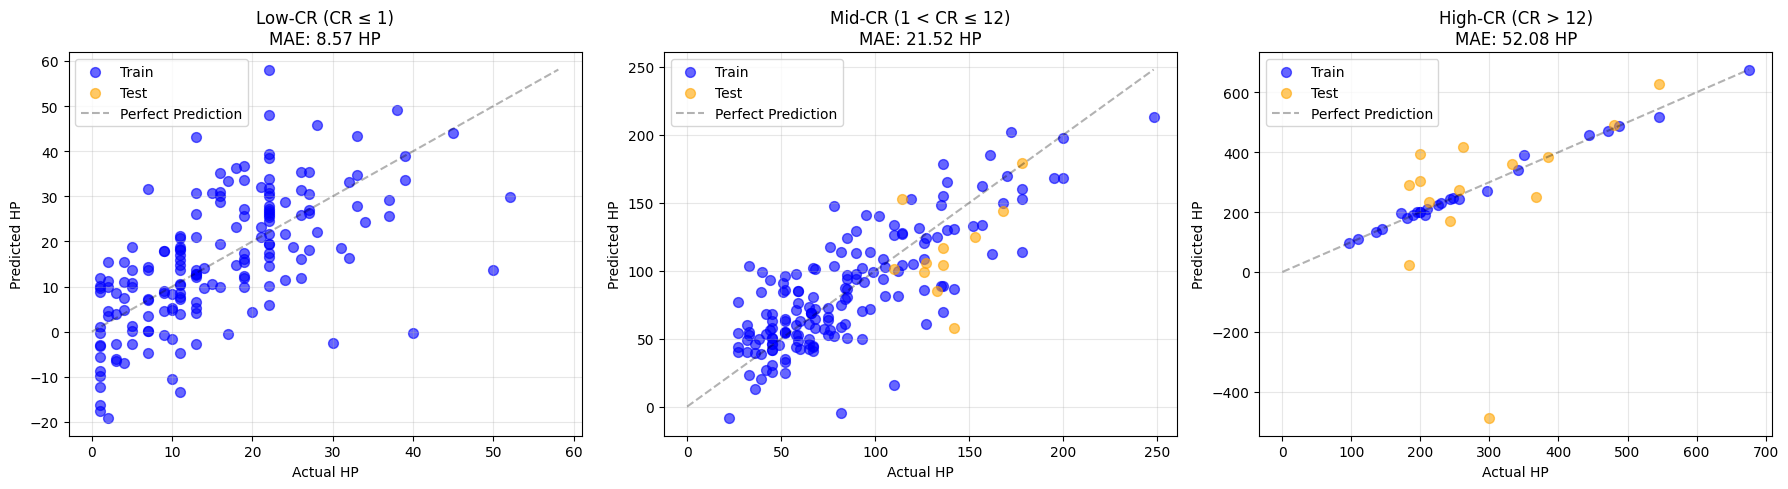


📊 VISUALIZATION: Error Distribution


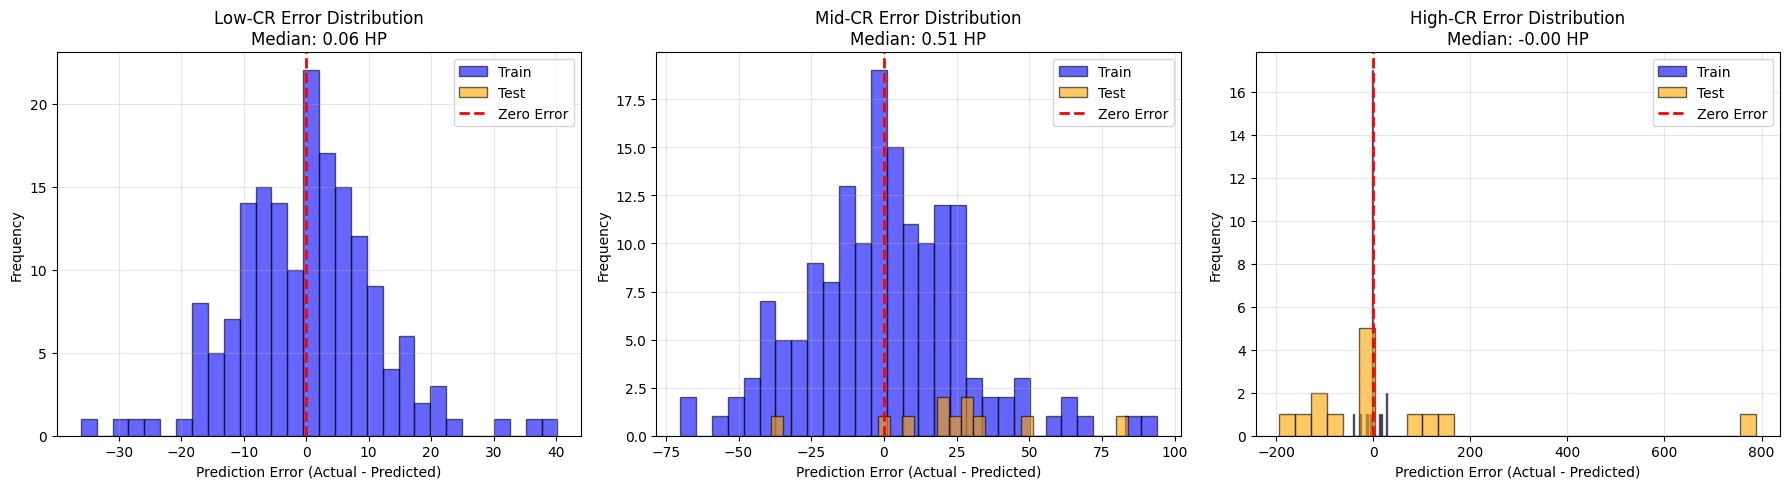

In [20]:
print("🔍 ANALYZING BEST AND WORST PREDICTIONS")
print("=" * 80)

def analyze_predictions(df_tier, y_actual, y_pred, tier_name, is_train):
    """Analyze prediction accuracy for a tier."""
    # Create analysis dataframe
    analysis = pd.DataFrame({
        'Name': df_tier['Name'].values,
        'CR': df_tier['cr_numeric'].values,
        'Actual_HP': y_actual,
        'Predicted_HP': y_pred,
        'Error': y_actual - y_pred,
        'Abs_Error': np.abs(y_actual - y_pred),
        'Pct_Error': ((y_actual - y_pred) / y_actual) * 100,
        'Split': ['Train' if t else 'Test' for t in is_train]
    })
    
    # Sort by absolute error
    analysis = analysis.sort_values('Abs_Error')
    
    # Get best and worst 10
    best_10 = analysis.head(10)
    worst_10 = analysis.tail(10)
    
    print(f"\n{tier_name} - Best 10 Predictions:")
    print(best_10[['Name', 'CR', 'Actual_HP', 'Predicted_HP', 'Error', 'Split']].to_string(index=False))
    
    print(f"\n{tier_name} - Worst 10 Predictions:")
    print(worst_10[['Name', 'CR', 'Actual_HP', 'Predicted_HP', 'Error', 'Split']].to_string(index=False))
    
    # Summary stats
    print(f"\n{tier_name} Summary:")
    print(f"  Total creatures: {len(analysis)}")
    print(f"  Training: {sum(is_train)} | Test: {sum(~is_train)}")
    print(f"  Mean Absolute Error: {analysis['Abs_Error'].mean():.2f} HP")
    print(f"  Median Absolute Error: {analysis['Abs_Error'].median():.2f} HP")
    print(f"  Max Error: {analysis['Abs_Error'].max():.2f} HP")
    print(f"  Mean % Error: {analysis['Pct_Error'].abs().mean():.2f}%")
    
    return analysis

# Analyze each tier using ALL creatures (train + test)

# Low-CR: All creatures (we used all for both train and test)
X_low_all_scaled = scaler_low.transform(X_low)
y_pred_low_residual = model_low.predict(X_low_all_scaled)
# Reconstruct full HP predictions
y_actual_low_full = df_low_cr['actual_hp'].values
y_pred_low_full = df_low_cr['hp_after_phase2'].values + y_pred_low_residual
is_train_low = np.ones(len(y_low), dtype=bool)  # All are training
analysis_low = analyze_predictions(
    df_low_cr, 
    y_actual_low_full, 
    y_pred_low_full, 
    "Low-CR (CR ≤ 1)", 
    is_train_low
)

# Mid-CR: Get predictions for all mid-CR creatures
X_mid_all_scaled = scaler_mid.transform(X_mid)
y_pred_mid_residual = model_mid.predict(X_mid_all_scaled)
# Reconstruct full HP predictions
y_actual_mid_full = df_mid_cr['actual_hp'].values
y_pred_mid_full = df_mid_cr['hp_after_phase2'].values + y_pred_mid_residual
# Create train/test indicator
is_train_mid = np.array([idx in X_train_mid.index for idx in X_mid.index])
analysis_mid = analyze_predictions(
    df_mid_cr, 
    y_actual_mid_full, 
    y_pred_mid_full, 
    "Mid-CR (1 < CR ≤ 12)", 
    is_train_mid
)

# High-CR: Get predictions for all high-CR creatures
X_high_all_scaled = scaler_high.transform(X_high)
y_pred_high_residual = model_high.predict(X_high_all_scaled)
# Reconstruct full HP predictions
y_actual_high_full = df_high_cr['actual_hp'].values
y_pred_high_full = df_high_cr['hp_after_phase2'].values + y_pred_high_residual
# Create train/test indicator
is_train_high = np.array([idx in X_train_high.index for idx in X_high.index])
analysis_high = analyze_predictions(
    df_high_cr, 
    y_actual_high_full, 
    y_pred_high_full, 
    "High-CR (CR > 12)", 
    is_train_high
)

# Create visualizations
print("\n" + "=" * 80)
print("📊 VISUALIZATION: Actual vs Predicted HP")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Low-CR scatter
ax = axes[0]
train_mask = analysis_low['Split'] == 'Train'
ax.scatter(analysis_low.loc[train_mask, 'Actual_HP'], 
           analysis_low.loc[train_mask, 'Predicted_HP'],
           alpha=0.6, s=50, color='blue', label='Train')
ax.scatter(analysis_low.loc[~train_mask, 'Actual_HP'], 
           analysis_low.loc[~train_mask, 'Predicted_HP'],
           alpha=0.6, s=50, color='orange', label='Test')
max_val = max(analysis_low['Actual_HP'].max(), analysis_low['Predicted_HP'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect Prediction')
ax.set_xlabel('Actual HP')
ax.set_ylabel('Predicted HP')
ax.set_title(f'Low-CR (CR ≤ 1)\nMAE: {analysis_low["Abs_Error"].mean():.2f} HP')
ax.legend()
ax.grid(True, alpha=0.3)

# Mid-CR scatter
ax = axes[1]
train_mask = analysis_mid['Split'] == 'Train'
ax.scatter(analysis_mid.loc[train_mask, 'Actual_HP'], 
           analysis_mid.loc[train_mask, 'Predicted_HP'],
           alpha=0.6, s=50, color='blue', label='Train')
ax.scatter(analysis_mid.loc[~train_mask, 'Actual_HP'], 
           analysis_mid.loc[~train_mask, 'Predicted_HP'],
           alpha=0.6, s=50, color='orange', label='Test')
max_val = max(analysis_mid['Actual_HP'].max(), analysis_mid['Predicted_HP'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect Prediction')
ax.set_xlabel('Actual HP')
ax.set_ylabel('Predicted HP')
ax.set_title(f'Mid-CR (1 < CR ≤ 12)\nMAE: {analysis_mid["Abs_Error"].mean():.2f} HP')
ax.legend()
ax.grid(True, alpha=0.3)

# High-CR scatter
ax = axes[2]
train_mask = analysis_high['Split'] == 'Train'
ax.scatter(analysis_high.loc[train_mask, 'Actual_HP'], 
           analysis_high.loc[train_mask, 'Predicted_HP'],
           alpha=0.6, s=50, color='blue', label='Train')
ax.scatter(analysis_high.loc[~train_mask, 'Actual_HP'], 
           analysis_high.loc[~train_mask, 'Predicted_HP'],
           alpha=0.6, s=50, color='orange', label='Test')
max_val = max(analysis_high['Actual_HP'].max(), analysis_high['Predicted_HP'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect Prediction')
ax.set_xlabel('Actual HP')
ax.set_ylabel('Predicted HP')
ax.set_title(f'High-CR (CR > 12)\nMAE: {analysis_high["Abs_Error"].mean():.2f} HP')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error distribution plots
print("\n" + "=" * 80)
print("📊 VISUALIZATION: Error Distribution")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Low-CR error distribution
ax = axes[0]
train_mask = analysis_low['Split'] == 'Train'
ax.hist(analysis_low.loc[train_mask, 'Error'], bins=30, alpha=0.6, 
        color='blue', label='Train', edgecolor='black')
ax.hist(analysis_low.loc[~train_mask, 'Error'], bins=30, alpha=0.6, 
        color='orange', label='Test', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error (Actual - Predicted)')
ax.set_ylabel('Frequency')
ax.set_title(f'Low-CR Error Distribution\nMedian: {analysis_low["Error"].median():.2f} HP')
ax.legend()
ax.grid(True, alpha=0.3)

# Mid-CR error distribution
ax = axes[1]
train_mask = analysis_mid['Split'] == 'Train'
ax.hist(analysis_mid.loc[train_mask, 'Error'], bins=30, alpha=0.6, 
        color='blue', label='Train', edgecolor='black')
ax.hist(analysis_mid.loc[~train_mask, 'Error'], bins=30, alpha=0.6, 
        color='orange', label='Test', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error (Actual - Predicted)')
ax.set_ylabel('Frequency')
ax.set_title(f'Mid-CR Error Distribution\nMedian: {analysis_mid["Error"].median():.2f} HP')
ax.legend()
ax.grid(True, alpha=0.3)

# High-CR error distribution
ax = axes[2]
train_mask = analysis_high['Split'] == 'Train'
ax.hist(analysis_high.loc[train_mask, 'Error'], bins=30, alpha=0.6, 
        color='blue', label='Train', edgecolor='black')
ax.hist(analysis_high.loc[~train_mask, 'Error'], bins=30, alpha=0.6, 
        color='orange', label='Test', edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel('Prediction Error (Actual - Predicted)')
ax.set_ylabel('Frequency')
ax.set_title(f'High-CR Error Distribution\nMedian: {analysis_high["Error"].median():.2f} HP')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Create Exportable and Interpretable export_df

In [21]:
print("\n📊 EXPORTING ENGINEERED FEATURES TO CSV")
print("=" * 80)

# Combine all three CR tiers back into one dataframe
export_df = pd.concat([df_low_cr, df_mid_cr, df_high_cr], ignore_index=False)

# Add predicted HP for all creatures
def get_prediction_for_creature(row):
    """Get the final HP prediction for a creature based on its CR tier."""
    cr = row['cr_numeric']
    
    if cr <= 1.0:
        # Low-CR model
        X = row[phase3_features].fillna(0).values.reshape(1, -1)
        X_scaled = scaler_low.transform(X)
        residual_pred = model_low.predict(X_scaled)[0]
        return row['hp_after_phase2'] + residual_pred
    elif cr <= 12.0:
        # Mid-CR model
        X = row[phase3_features].fillna(0).values.reshape(1, -1)
        X_scaled = scaler_mid.transform(X)
        residual_pred = model_mid.predict(X_scaled)[0]
        return row['hp_after_phase2'] + residual_pred
    else:
        # High-CR model
        X = row[phase3_features].fillna(0).values.reshape(1, -1)
        X_scaled = scaler_high.transform(X)
        residual_pred = model_high.predict(X_scaled)[0]
        return row['hp_after_phase2'] + residual_pred

export_df['predicted_hp'] = export_df.apply(get_prediction_for_creature, axis=1)

# Add hp_delta (predicted - actual)
export_df['hp_delta'] = export_df['predicted_hp'] - export_df['actual_hp']

# Add hp_delta_pct (delta as % of actual HP)
export_df['hp_delta_pct'] = (export_df['hp_delta'] / export_df['actual_hp']) * 100

# Add percentile of hp_delta_pct within each CR tier
def add_percentile_by_cr(df):
    """Add percentile ranking of absolute hp_delta_pct within each CR tier."""
    df['hp_delta_pct_percentile'] = 0.0
    
    # Low-CR percentile
    low_cr_mask = df['cr_numeric'] <= 1.0
    if low_cr_mask.any():
        abs_pct = df.loc[low_cr_mask, 'hp_delta_pct'].abs()
        df.loc[low_cr_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    # Mid-CR percentile
    mid_cr_mask = (df['cr_numeric'] > 1.0) & (df['cr_numeric'] <= 12.0)
    if mid_cr_mask.any():
        abs_pct = df.loc[mid_cr_mask, 'hp_delta_pct'].abs()
        df.loc[mid_cr_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    # High-CR percentile
    high_cr_mask = df['cr_numeric'] > 12.0
    if high_cr_mask.any():
        abs_pct = df.loc[high_cr_mask, 'hp_delta_pct'].abs()
        df.loc[high_cr_mask, 'hp_delta_pct_percentile'] = abs_pct.rank(pct=True) * 100
    
    return df

export_df = add_percentile_by_cr(export_df)

# Select columns to export
columns_to_export = [
    # Identifying information
    'Name', 'Type', 'Size', 'Challenge_Rating', 'cr_numeric',
    
    # Original stats
    'HP', 'actual_hp', 'AC', 'ac_value',
    
    # Predictions and errors
    'predicted_hp', 'hp_delta', 'hp_delta_pct', 'hp_delta_pct_percentile',
    
    # Baselines
    'hp_baseline', 'ac_baseline', 'attack_baseline', 'dpr_baseline', 'dc_baseline',
    
    # Combat stats
    'highest_attack_bonus', 'highest_save_dc', 'estimated_dpr', 'legendary_dpr', 'total_dpr',
    
    # Phase 2: Deviations
    'ac_deviation', 'attack_deviation', 'dpr_deviation', 'save_dc_deviation',
    
    # Phase intermediates
    'hp_after_phase1_5', 'hp_after_phase2', 'residual_hp',
    
    # Phase 3: Scaled features (if they exist)
    'has_legendary_resistance_scaled', 
    'has_magic_resistance_scaled', 'has_regeneration_scaled',
    
    # Phase 3: Movement
    'speed_ground', 'speed_fly', 'speed_swim', 'speed_burrow', 'speed_climb',
    'max_speed', 'movement_types_count', 'has_flying',
    
    # Phase 3: Defenses
    'save_proficiency_count', 'skill_proficiency_count',
    'resistance_count', 'immunity_count', 'vulnerability_count', 
    'condition_immunity_count',
    
    # Phase 3: Senses
    'has_darkvision', 'darkvision_range', 'has_blindsight', 
    'has_truesight', 'has_tremorsense', 'passive_perception',
    
    # Phase 3: Abilities
    'trait_count', 'action_count', 'reaction_count', 'bonus_action_count',
    'legendary_action_count', 'legendary_actions_per_round',
    'total_ability_count',
    
    # Phase 3: Special abilities
    'has_legendary_actions', 'has_legendary_resistance', 
    'has_magic_resistance', 'has_regeneration',
    'has_spellcasting', 'spellcaster_level',
    'size_ordinal', 'has_grapple',
    
    # Phase 3: Condition infliction
    'inflicts_poisoned', 'inflicts_blinded', 'inflicts_charmed',
    'inflicts_deafened', 'inflicts_frightened', 'inflicts_incapacitated',
    'inflicts_paralyzed', 'inflicts_petrified', 'inflicts_prone',
    'inflicts_restrained', 'inflicts_stunned'
]

# Filter to only columns that exist in the dataframe
existing_columns = [col for col in columns_to_export if col in export_df.columns]
export_data = export_df[existing_columns].copy()

# Sort by CR for easier inspection
export_data = export_data.sort_values('cr_numeric')

# Export to CSV
output_path = f'{DATA_DIR}/engineered_features.csv'
export_data.to_csv(output_path, index=False)

print(f"✅ Exported {len(export_data)} monsters with {len(existing_columns)} features")
print(f"✅ Saved to: {output_path}")

print("\n📋 Exported Columns:")
print(f"   - Identification: Name, Type, Size, CR")
print(f"   - Predictions: predicted_hp, hp_delta, hp_delta_pct, hp_delta_pct_percentile")
print(f"   - Original Stats: HP, AC, Attack, DPR, Save DC")
print(f"   - Baselines: hp_baseline, ac_baseline, etc.")
print(f"   - Phase intermediates: hp_after_phase1_5, hp_after_phase2, residual_hp")
print(f"   - Phase 3: All {len(phase3_features)} engineered features")

print(f"\n🔍 Sample of exported data:")
display(export_data[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta', 
                      'hp_delta_pct', 'hp_delta_pct_percentile']].head(15))


📊 EXPORTING ENGINEERED FEATURES TO CSV


/tmp/ipykernel_62197/1377823841.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = row[phase3_features].fillna(0).values.reshape(1, -1)
/home/codespace/.python/current/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_62197/1377823841.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = row[phase3_features].fillna(0).values.reshape(1, -1)
/home/codespace/.python/current/lib/python3.12/site-packages/skle

✅ Exported 382 monsters with 79 features
✅ Saved to: ../data/engineered_features.csv

📋 Exported Columns:
   - Identification: Name, Type, Size, CR
   - Predictions: predicted_hp, hp_delta, hp_delta_pct, hp_delta_pct_percentile
   - Original Stats: HP, AC, Attack, DPR, Save DC
   - Baselines: hp_baseline, ac_baseline, etc.
   - Phase intermediates: hp_after_phase1_5, hp_after_phase2, residual_hp
   - Phase 3: All 41 engineered features

🔍 Sample of exported data:


/tmp/ipykernel_62197/1377823841.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = row[phase3_features].fillna(0).values.reshape(1, -1)
/home/codespace/.python/current/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_62197/1377823841.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = row[phase3_features].fillna(0).values.reshape(1, -1)
/home/codespace/.python/current/lib/python3.12/site-packages/skle

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile
27,Animated Object (Huge),0.0,40,-0.221786,-4.022179e+01,-1.005545e+02,72.674419
30,Animated Object (Tiny),0.0,10,-10.593868,-2.059387e+01,-2.059387e+02,86.046512
29,Animated Object (Small or Medium),0.0,10,-1.530844,-1.153084e+01,-1.153084e+02,77.325581
28,Animated Object (Large),0.0,20,4.246702,-1.575330e+01,-7.876649e+01,62.209302
45,Badger,0.0,3,-6.502165,-9.502165e+00,-3.167388e+02,90.116279
44,Baboon,0.0,3,3.921877,9.218771e-01,3.072924e+01,33.720930
39,Awakened Shrub,0.0,10,5.257198,-4.742802e+00,-4.742802e+01,47.093023
38,Avatar of Death,0.0,1,1.000000,3.552714e-14,3.552714e-12,3.488372
88,Crab,0.0,2,11.194145,9.194145e+00,4.597072e+02,93.023256
112,Eagle,0.0,3,-6.034033,-9.034033e+00,-3.011344e+02,89.534884


## Export Feature contributions

In [22]:
print("\n📊 EXPORTING FEATURE CONTRIBUTIONS TO CSV")
print("=" * 80)

# Combine all three CR tiers
all_creatures = pd.concat([df_low_cr, df_mid_cr, df_high_cr], ignore_index=False)

# Create feature contributions dataframe
contributions_list = []

for idx, row in all_creatures.iterrows():
    cr = row['cr_numeric']
    creature_data = {
        'Name': row['Name'],
        'CR': cr,
        'actual_hp': row['actual_hp'],
        'hp_baseline': row['hp_baseline'],
    }
    
    # Phase 1.5 contributions (resistances/immunities)
    creature_data['phase1_5_resistance_penalty'] = -row.get('resistance_penalty', 0)
    creature_data['phase1_5_immunity_penalty'] = -row.get('immunity_penalty', 0)
    creature_data['phase1_5_total_penalty'] = -row.get('total_defensive_penalty', 0)
    creature_data['hp_after_phase1_5'] = row.get('hp_after_phase1_5', row['hp_baseline'])
    
    # Phase 2 contributions (combat stat deviations + flying)
    if cr <= 1.0:
        penalties = PHASE2_PENALTIES_LOW
    elif cr <= 12.0:
        penalties = PHASE2_PENALTIES_MID
    else:
        penalties = PHASE2_PENALTIES_HIGH
    
    creature_data['phase2_ac_contribution'] = row['ac_deviation'] * penalties['ac_deviation']
    creature_data['phase2_attack_contribution'] = row['attack_deviation'] * penalties['attack_deviation']
    creature_data['phase2_dpr_contribution'] = row['dpr_deviation'] * penalties['dpr_deviation']
    creature_data['phase2_save_dc_contribution'] = row['save_dc_deviation'] * penalties['save_dc_deviation']
    creature_data['phase2_flying_contribution'] = row['has_flying'] * penalties['has_flying']
    creature_data['phase2_total_contribution'] = sum([
        creature_data['phase2_ac_contribution'],
        creature_data['phase2_attack_contribution'],
        creature_data['phase2_dpr_contribution'],
        creature_data['phase2_save_dc_contribution'],
        creature_data['phase2_flying_contribution']
    ])
    creature_data['hp_after_phase2'] = row['hp_after_phase2']
    
    # Phase 3 contributions (learned features)
    # Get the features and model for this CR tier
    if cr <= 1.0:
        model = model_low
        scaler = scaler_low
    elif cr <= 12.0:
        model = model_mid
        scaler = scaler_mid
    else:
        model = model_high
        scaler = scaler_high
    
    # Get feature values
    X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
    X_scaled = scaler.transform(X_features)
    
    # Calculate contribution of each feature
    coefficients = model.coef_
    intercept = model.intercept_
    
    # Feature contributions = scaled_feature * coefficient
    feature_contributions = X_scaled[0] * coefficients
    
    # Add intercept contribution
    creature_data['phase3_intercept'] = intercept
    
    # Add individual feature contributions
    for feat_name, contrib in zip(phase3_features, feature_contributions):
        creature_data[f'phase3_{feat_name}'] = contrib
    
    # Total Phase 3 contribution (residual)
    creature_data['phase3_total_contribution'] = intercept + feature_contributions.sum()
    
    # Final prediction
    creature_data['predicted_hp'] = row['hp_after_phase2'] + creature_data['phase3_total_contribution']
    creature_data['hp_error'] = creature_data['actual_hp'] - creature_data['predicted_hp']
    creature_data['hp_error_pct'] = (creature_data['hp_error'] / creature_data['actual_hp']) * 100
    
    contributions_list.append(creature_data)

# Create dataframe
contributions_df = pd.DataFrame(contributions_list)

# Save to CSV
output_path = f'{DATA_DIR}/feature_contributions.csv'
contributions_df.to_csv(output_path, index=False)

print(f"✅ Saved feature contributions to: {output_path}")
print(f"   Rows: {len(contributions_df)}")
print(f"   Columns: {len(contributions_df.columns)}")
print(f"\n   Columns include:")
print(f"     - Basic info: Name, CR, actual_hp, hp_baseline")
print(f"     - Phase 1.5: resistance/immunity penalties")
print(f"     - Phase 2: AC, attack, DPR, save DC, flying contributions")
print(f"     - Phase 3: Intercept + {len(phase3_features)} feature contributions")
print(f"     - Final: predicted_hp, hp_error, hp_error_pct")


/tmp/ipykernel_62197/1842258535.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
/home/codespace/.python/current/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_62197/1842258535.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_features = row[phase3_features].fillna(0).values.reshape(1, -1)
/home/codespace/.python/current/lib/python3.12/


📊 EXPORTING FEATURE CONTRIBUTIONS TO CSV


✅ Saved feature contributions to: ../data/feature_contributions.csv
   Rows: 382
   Columns: 61

   Columns include:
     - Basic info: Name, CR, actual_hp, hp_baseline
     - Phase 1.5: resistance/immunity penalties
     - Phase 2: AC, attack, DPR, save DC, flying contributions
     - Phase 3: Intercept + 41 feature contributions
     - Final: predicted_hp, hp_error, hp_error_pct


# Feature Contribution Analysis

Detailed analysis of feature contributions for creatures with high prediction errors.

In [23]:
print("=" * 80)
print("📊 FEATURE CONTRIBUTION ANALYSIS")
print("=" * 80)

# Show top 10 creatures with highest absolute error
print("\nTOP 10 CREATURES WITH HIGHEST ABSOLUTE ERROR:")
print("-" * 80)

contributions_df['abs_error'] = contributions_df['hp_error'].abs()
top_10 = contributions_df.nlargest(10, 'abs_error')[
    ['Name', 'CR', 'actual_hp', 'predicted_hp', 'hp_error', 
     'phase2_total_contribution', 'phase3_total_contribution']
].copy()

for col in ['predicted_hp', 'hp_error', 'phase2_total_contribution', 'phase3_total_contribution']:
    top_10[col] = top_10[col].round(2)

print(top_10.to_string(index=False))

# Detailed breakdown function
def show_creature_breakdown(creature_name):
    """Show detailed feature contribution breakdown for a creature."""
    creature = contributions_df[contributions_df['Name'] == creature_name].iloc[0]
    
    print(f"\n{'=' * 80}")
    print(f"DETAILED BREAKDOWN: {creature_name}")
    print("=" * 80)
    print()
    print(f"Actual HP: {creature['actual_hp']:.0f}")
    print(f"Predicted HP: {creature['predicted_hp']:.2f}")
    print(f"Error: {creature['hp_error']:.2f} HP ({creature['hp_error_pct']:.2f}%)")
    print()
    
    print("PHASE BREAKDOWN:")
    print("-" * 80)
    print(f"Baseline (Phase 1):                    {creature['hp_baseline']:>8.0f}")
    print()
    
    print("Phase 1.5 (Resistances/Immunities):")
    print(f"  Resistance penalty:                  {creature['phase1_5_resistance_penalty']:>8.0f}")
    print(f"  Immunity penalty:                    {creature['phase1_5_immunity_penalty']:>8.0f}")
    print(f"  Total defensive penalty:             {creature['phase1_5_total_penalty']:>8.0f}")
    print(f"  After Phase 1.5:                     {creature['hp_after_phase1_5']:>8.0f}")
    print()
    
    print("Phase 2 (Combat Stats):")
    print(f"  AC deviation contribution:           {creature['phase2_ac_contribution']:>8.0f}")
    print(f"  Attack deviation contribution:       {creature['phase2_attack_contribution']:>8.0f}")
    print(f"  DPR deviation contribution:          {creature['phase2_dpr_contribution']:>8.0f}")
    print(f"  Save DC deviation contribution:      {creature['phase2_save_dc_contribution']:>8.0f}")
    print(f"  Flying contribution:                 {creature['phase2_flying_contribution']:>8.0f}")
    print(f"  Phase 2 total:                       {creature['phase2_total_contribution']:>8.0f}")
    print(f"  After Phase 2:                       {creature['hp_after_phase2']:>8.0f}")
    print()
    
    print("Phase 3 (Learned Features) - Top 15 contributors:")
    # Get all phase3 feature contributions
    phase3_cols = [col for col in contributions_df.columns if col.startswith('phase3_') 
                   and col not in ['phase3_intercept', 'phase3_total_contribution']]
    
    phase3_contribs = []
    for feat in phase3_cols:
        feat_name = feat.replace('phase3_', '')
        value = creature[feat]
        if abs(value) > 0.01:  # Only show non-zero contributions
            phase3_contribs.append((feat_name, value))
    
    # Sort by absolute contribution
    phase3_contribs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Show top 15
    for feat_name, value in phase3_contribs[:15]:
        print(f"  {feat_name:40s} {value:>8.2f}")
    
    print()
    print(f"  Intercept:                           {creature['phase3_intercept']:>8.2f}")
    print(f"  Phase 3 total:                       {creature['phase3_total_contribution']:>8.2f}")
    print()
    
    print("-" * 80)
    print(f"FINAL PREDICTED HP:                    {creature['predicted_hp']:>8.2f}")
    print(f"ACTUAL HP:                             {creature['actual_hp']:>8.0f}")
    print(f"ERROR:                                 {creature['hp_error']:>8.2f}")

# Show detailed breakdowns for top 3 worst predictions
print("\n" + "=" * 80)
print("DETAILED BREAKDOWNS FOR TOP 3 WORST PREDICTIONS")
print("=" * 80)

for idx, row in top_10.head(3).iterrows():
    show_creature_breakdown(row['Name'])

# Show summary statistics
print("\n" + "=" * 80)
print("SUMMARY: Feature Contribution Patterns")
print("=" * 80)

print("\nPhase 2 contribution statistics:")
for col in ['phase2_ac_contribution', 'phase2_attack_contribution', 
            'phase2_dpr_contribution', 'phase2_save_dc_contribution', 'phase2_flying_contribution']:
    mean_val = contributions_df[col].mean()
    std_val = contributions_df[col].std()
    print(f"  {col:40s} μ={mean_val:>7.2f}  σ={std_val:>7.2f}")

print("\nPhase 3 contribution statistics:")
phase3_mean = contributions_df['phase3_total_contribution'].mean()
phase3_std = contributions_df['phase3_total_contribution'].std()
print(f"  Phase 3 total contribution:            μ={phase3_mean:>7.2f}  σ={phase3_std:>7.2f}")

print("\n" + "=" * 80)
print("✅ Feature contribution analysis complete")
print("   See data/feature_contributions.csv for full details")
print("=" * 80)


📊 FEATURE CONTRIBUTION ANALYSIS

TOP 10 CREATURES WITH HIGHEST ABSOLUTE ERROR:
--------------------------------------------------------------------------------
                Name   CR  actual_hp  predicted_hp  hp_error  phase2_total_contribution  phase3_total_contribution
           Pit Fiend 20.0        300       -488.95    788.95                      206.0                    -784.95
            Planetar 16.0        200        392.87   -192.87                      322.5                       1.67
          Nalfeshnee 13.0        184         22.87    161.13                       92.0                    -124.33
               Balor 19.0        262        418.84   -156.84                      180.5                     152.84
Ancient Black Dragon 21.0        367        250.97    116.03                      245.5                     -92.03
 Adult Copper Dragon 14.0        184        289.98   -105.98                      144.0                      87.18
  Adult White Dragon 13.0        20

# My Analysis

In [151]:
export_df.sort_values('actual_hp').loc[:, ['actual_hp']+list(export_df.columns)].head()

,actual_hp,Name,Size,Type,Alignment,HP,AC,Speed,Challenge_Rating,XP,...,family,hp_after_phase2,has_legendary_resistance_scaled,has_magic_resistance_scaled,has_regeneration_scaled,residual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile
38,1,Avatar of Death,Medium,Undead,Neutral Evil,1 (1d1),20,"60 ft., Fly 60 ft. (hover)",0,0,...,other,-22.875,-0.0,-0.0,-0.0,23.875,1.000000,3.552714e-14,3.552714e-12,3.488372
125,1,Frog,Tiny,beast,Unaligned,1 (1d4-1),11,"20 ft., swim 20 ft.",0,10,...,beast,9.125,0.0,0.0,0.0,-8.125,11.123879,1.012388e+01,1.012388e+03,95.930233
271,1,Quipper,Tiny,beast,Unaligned,1 (1d4-1),13,Swim 40 ft.,0,10,...,other,-18.375,-0.0,-0.0,-0.0,19.375,-18.446218,-1.944622e+01,-1.944622e+03,100.000000
273,1,Rat,Tiny,beast,Unaligned,1 (1d4-1),10,20 ft.,0,10,...,beast,10.625,0.0,0.0,0.0,-9.625,8.776718,7.776718e+00,7.776718e+02,94.767442
274,1,Raven,Tiny,beast,Unaligned,1 (1d4-1),12,"10 ft., fly 50 ft.",0,10,...,other,-16.375,-0.0,-0.0,-0.0,17.375,-11.065107,-1.206511e+01,-1.206511e+03,98.255814


In [152]:
export_df[export_df['Name']=='Archmage'].loc[:, [col for col in export_df.columns if 'hp' in col.lower()]]

,HP,hp_baseline,actual_hp,hp_after_phase1,hp_after_phase1_5,hp_after_phase2,residual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile
36,99 (18d8+18),210.0,99,210.0,52.5,276.75,-177.75,99.0,5.400125e-13,5.454672e-13,1.169591


In [26]:
analysis_low.sort_values('Actual_HP').head()

,Name,CR,Actual_HP,Predicted_HP,Error,Abs_Error,Pct_Error,Split
8,Avatar of Death,0.0,1,1.000000,-3.552714e-14,3.552714e-14,-3.552714e-12,Train
133,Sea Horse,0.0,1,-0.257803,1.257803e+00,1.257803e+00,1.257803e+02,Train
114,Piranha,0.0,1,-2.960614,3.960614e+00,3.960614e+00,3.960614e+02,Train
112,Owl,0.0,1,-3.081323,4.081323e+00,4.081323e+00,4.081323e+02,Train
124,Raven,0.0,1,-9.745157,1.074516e+01,1.074516e+01,1.074516e+03,Train


In [154]:
analysis_mid.sort_values('Predicted_HP').iloc[[rr for rr in range(5)], :]

,Name,CR,Actual_HP,Predicted_HP,Error,Abs_Error,Pct_Error,Split
120,Roper,5.0,93,-35.404332,128.404332,128.404332,138.069174,Train
64,Gibbering Mouther,2.0,67,-21.995087,88.995087,88.995087,132.828488,Train
156,Will-o'-Wisp,2.0,22,-4.619723,26.619723,26.619723,120.998742,Train
70,Green Hag,3.0,82,-3.189795,85.189795,85.189795,103.889994,Train
136,Swarm of Venomous Snakes,2.0,36,12.215444,23.784556,23.784556,66.068211,Train


In [28]:
contributions_df[contributions_df['Name'] == 'Roper']

,Name,CR,actual_hp,hp_baseline,phase1_5_resistance_penalty,phase1_5_immunity_penalty,phase1_5_total_penalty,hp_after_phase1_5,phase2_ac_contribution,phase2_attack_contribution,...,phase3_inflicts_paralyzed,phase3_inflicts_petrified,phase3_inflicts_prone,phase3_inflicts_restrained,phase3_inflicts_stunned,phase3_total_contribution,predicted_hp,hp_error,hp_error_pct,abs_error
292,Roper,5.0,93,114.0,-28.5,-57.0,-85.5,28.5,-25.0,-0.0,...,0.205942,-0.176251,2.529894,15.255479,-0.272217,65.898132,101.898132,-8.898132,-9.567884,8.898132


In [29]:
analysis_high.sort_values('Predicted_HP').iloc[[0, 1, -1, -2], :]

,Name,CR,Actual_HP,Predicted_HP,Error,Abs_Error,Pct_Error,Split
30,Pit Fiend,20.0,300,-488.950367,7.889504e+02,7.889504e+02,2.629835e+02,Test
29,Nalfeshnee,13.0,184,22.868662,1.611313e+02,1.611313e+02,8.757138e+01,Test
37,Tarrasque,30.0,676,676.000000,-6.821210e-13,6.821210e-13,-1.009055e-13,Train
15,Ancient Gold Dragon,24.0,546,628.254001,-8.225400e+01,8.225400e+01,-1.506484e+01,Test


In [158]:
creature_name = 'Pit Fiend'
_inspect_index = contributions_df[contributions_df['Name'] == creature_name].index

for col in contributions_df.columns:
    name_len = len(col)
    long_len = 40
    pad_length = long_len - name_len
    col_val = contributions_df.loc[_inspect_index, col]
    try:
        print(col, " "*pad_length + "{:,.0f}".format(float(col_val)))
    except:
        print(col, col_val)

Name 373    Pit Fiend
Name: Name, dtype: object
CR                                       20
actual_hp                                300
hp_baseline                              360
phase1_5_resistance_penalty              -270
phase1_5_immunity_penalty                -360
phase1_5_total_penalty                   -270
hp_after_phase1_5                        90
phase2_ac_contribution                   14
phase2_attack_contribution               -8
phase2_dpr_contribution                  114
phase2_save_dc_contribution              -0
phase2_flying_contribution               -10
phase2_total_contribution                110
hp_after_phase2                          200
phase3_intercept                         -33
phase3_has_legendary_resistance_scaled   -90
phase3_has_magic_resistance_scaled       43
phase3_has_regeneration_scaled           7
phase3_speed_ground                      11
phase3_speed_fly                         16
phase3_speed_swim                        -36
phase3_speed_b

/tmp/ipykernel_3222/32002411.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(col, " "*pad_length + "{:,.0f}".format(float(col_val)))


In [157]:
_inspect_index = export_df[export_df['Name'] == creature_name].index

for col in export_df.columns:
    if col in ["Traits", "Actions"]:
        continue
    name_len = len(col)
    long_len = 40
    pad_length = long_len - name_len
    col_val = export_df.loc[_inspect_index, col]

    try:
        print(col, " "*pad_length + "{:,.0f}".format(float(col_val)))
    except:
        print(col, col_val)

Name 281    Roper
Name: Name, dtype: object
Size 281    Large
Name: Size, dtype: object
Type 281    monstrosity
Name: Type, dtype: object
Alignment 281    Neutral Evil
Name: Alignment, dtype: object
HP 281    93 (11d10+33)
Name: HP, dtype: object
AC 281    20 (Natural Armor)
Name: AC, dtype: object
Speed 281    10 ft., climb 10 ft.
Name: Speed, dtype: object
Challenge_Rating                         5
XP 281    1,800
Name: XP, dtype: object
STR                                      18
STR_Mod                                  4
DEX                                      8
DEX_Mod                                  -1
CON                                      17
CON_Mod                                  3
INT                                      7
INT_Mod                                  -2
WIS                                      16
WIS_Mod                                  3
CHA                                      6
CHA_Mod                                  -2
Saving_Throws 281    —
Name: Savin

/tmp/ipykernel_3222/654030143.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(col, " "*pad_length + "{:,.0f}".format(float(col_val)))
